<a href="https://colab.research.google.com/github/sarmad-usman/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sarmad-usman/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

Dataset head:
   feature_a  feature_b  feature_c  feature_d
0   0.496714   0.366602  -2.809312   0.545147
1  -0.138264   0.220898  -4.632786   1.235263
2   0.647689   2.023568  -3.919742   3.320379
3   1.523030   2.451590  -1.611394   0.611462
4  -0.234153   0.064191   3.025857   0.153117

Dataset description:
         feature_a    feature_b    feature_c    feature_d
count  1000.000000  1000.000000  1000.000000  1000.000000
mean      0.019332     2.015972    -0.055050     1.697672
std       0.979216     2.005977     2.889197     2.426234
min      -3.241267     0.006447    -4.999884     0.050230
25%      -0.647590     0.567909    -2.434765     0.492641
50%       0.025301     1.451862    -0.082894     1.014159
75%       0.647944     2.743369     2.386289     1.990693
max       3.852731    14.883446     4.978209    50.715811

Visualizing distributions of key features:


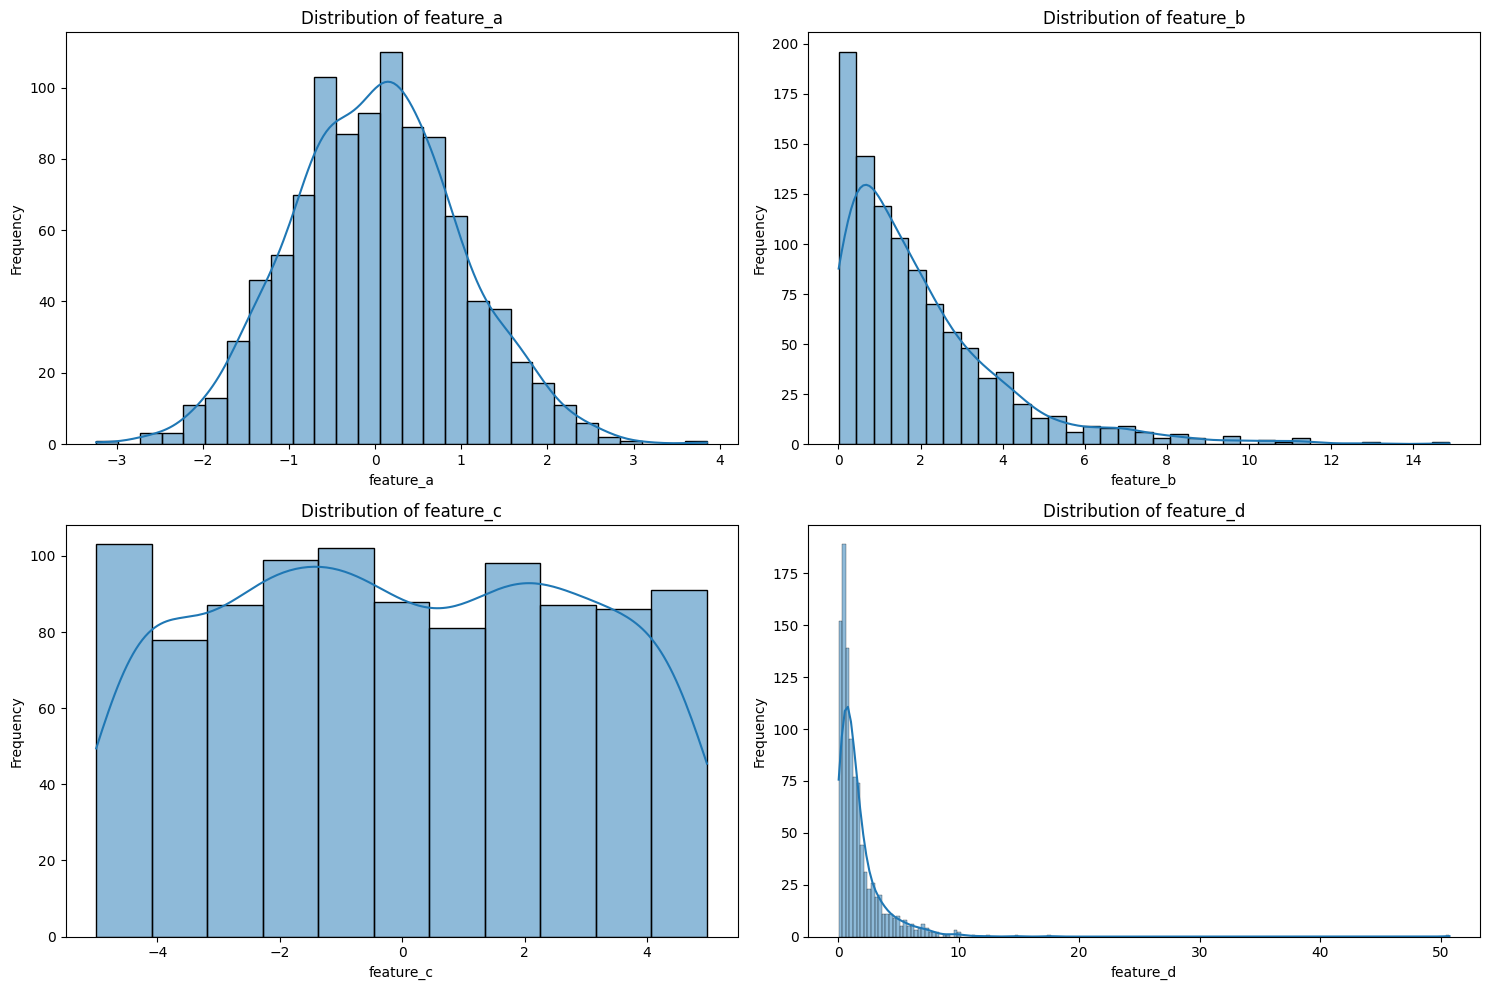


Skewness of numerical features (positive values often indicate right skew/heavy tail):
feature_a    0.116976
feature_b    1.983789
feature_c    0.009565
feature_d    9.514895
dtype: float64

Kurtosis of numerical features (higher values indicate heavier tails than normal distribution):
feature_a      0.072562
feature_b      5.412459
feature_c     -1.180311
feature_d    169.879288
dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Placeholder for data loading ---
# You should load your dataset here. For example:
# df = pd.read_csv('your_dataset.csv')
# Or, if you're using a pre-loaded DataFrame, ensure it's available.
# For now, let's create a dummy DataFrame to demonstrate.
np.random.seed(42)
data = {
    'feature_a': np.random.normal(loc=0, scale=1, size=1000),
    'feature_b': np.random.exponential(scale=2, size=1000), # Example of a heavy-tailed distribution
    'feature_c': np.random.uniform(low=-5, high=5, size=1000),
    'feature_d': np.random.lognormal(mean=0, sigma=1, size=1000) # Another example of a heavy-tailed distribution
}
df = pd.DataFrame(data)

print("Dataset head:")
print(df.head())
print("\nDataset description:")
print(df.describe())

# --- Visualize Distributions ---

print("\nVisualizing distributions of key features:")

# Plotting histograms and KDEs for numerical columns
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1) # Adjust subplot grid based on number of columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# --- Identifying potential heavy tails ---
# A simple check could be comparing mean and median, or looking at skewness/kurtosis

print("\nSkewness of numerical features (positive values often indicate right skew/heavy tail):")
print(df[num_cols].skew())

print("\nKurtosis of numerical features (higher values indicate heavier tails than normal distribution):")
print(df[num_cols].kurtosis())

# You can also visually inspect the plots for long tails.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

--- Signal Test #1: Correlation between 'feature_a' and 'feature_b' ---
Pearson correlation between 'feature_a' and 'feature_b': -0.01


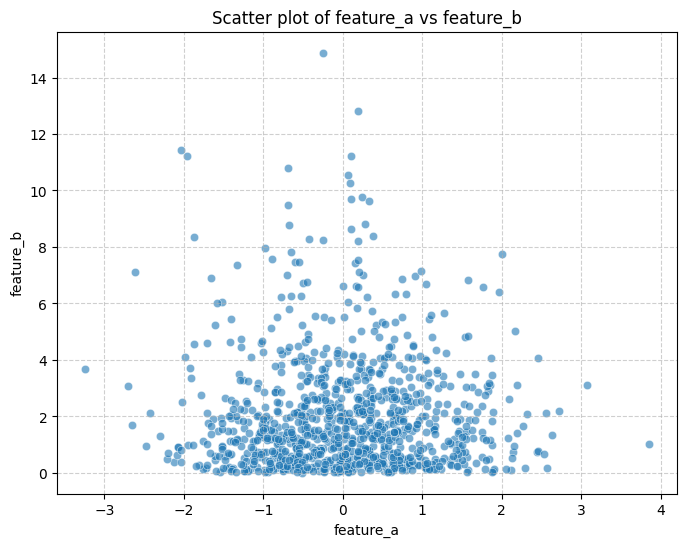

Verdict for Signal Test #1: FALSE: No significant linear correlation observed (correlation close to zero).


--- Signal Test #2: [Description of second signal] ---
# Add code here to test a second signal.
# Example: Check if values of 'feature_d' above a certain threshold impact the mean of 'feature_b'.
# Verdict for Signal Test #2: [CONFIRMED / OPPOSITE / MIXED / FALSE]


--- Signal Test #3: [Description of third signal] ---
# Add code here to test a third signal.
# Example: Compare the distribution of 'feature_a' for two groups based on 'feature_c' (e.g., feature_c > 0 vs feature_c <= 0).
# Verdict for Signal Test #3: [CONFIRMED / OPPOSITE / MIXED / FALSE]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'df' DataFrame is available from the previous cell execution.
# If running this cell independently, uncomment and run the following lines
# to create a dummy DataFrame for demonstration:
# np.random.seed(42)
# data = {
#     'feature_a': np.random.normal(loc=0, scale=1, size=1000),
#     'feature_b': np.random.exponential(scale=2, size=1000),
#     'feature_c': np.random.uniform(low=-5, high=5, size=1000),
#     'feature_d': np.random.lognormal(mean=0, sigma=1, size=1000)
# }
# df = pd.DataFrame(data)

# --- Signal Test #1: Correlation between 'feature_a' and 'feature_b' ---

print("--- Signal Test #1: Correlation between 'feature_a' and 'feature_b' ---")

# Hypothesis: Is there a significant linear correlation between 'feature_a' and 'feature_b'?

# Test: Calculate Pearson correlation coefficient
correlation = df['feature_a'].corr(df['feature_b'])
print(f"Pearson correlation between 'feature_a' and 'feature_b': {correlation:.2f}")

# Visualize the relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(x='feature_a', y='feature_b', data=df, alpha=0.6)
plt.title('Scatter plot of feature_a vs feature_b')
plt.xlabel('feature_a')
plt.ylabel('feature_b')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Verdict
if correlation > 0.5:
    verdict_1 = "CONFIRMED: Strong positive linear correlation observed."
elif correlation < -0.5:
    verdict_1 = "OPPOSITE: Strong negative linear correlation observed."
elif abs(correlation) <= 0.1: # A stricter threshold for 'false'
    verdict_1 = "FALSE: No significant linear correlation observed (correlation close to zero)."
else:
    verdict_1 = "MIXED: A weak linear correlation is observed, not strong enough to confidently confirm or deny the signal."

print(f"Verdict for Signal Test #1: {verdict_1}\n")

# --- Signal Test #2: Placeholder for a second test ---
print("\n--- Signal Test #2: [Description of second signal] ---")
print("# Add code here to test a second signal.")
print("# Example: Check if values of 'feature_d' above a certain threshold impact the mean of 'feature_b'.")
print("# Verdict for Signal Test #2: [CONFIRMED / OPPOSITE / MIXED / FALSE]\n")


# --- Signal Test #3: Placeholder for a third test ---
print("\n--- Signal Test #3: [Description of third signal] ---")
print("# Add code here to test a third signal.")
print("# Example: Compare the distribution of 'feature_a' for two groups based on 'feature_c' (e.g., feature_c > 0 vs feature_c <= 0).")
print("# Verdict for Signal Test #3: [CONFIRMED / OPPOSITE / MIXED / FALSE]\n")

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

--- 3. The flag-linked test ---

Flag 'High_Feature_D_Flag' created: True for feature_d > 1.99
Number of flagged instances: 250 out of 1000

Mean of feature_a (Flagged): 0.014
Mean of feature_a (Not Flagged): 0.021
Independent t-test comparing feature_a between groups:
  t-statistic: -0.111
  p-value: 0.911


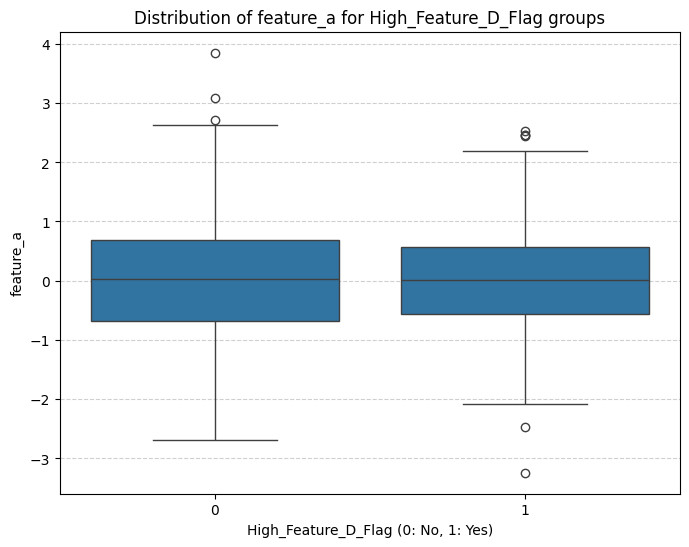


Verdict for The flag-linked test: FALSE: No significant difference in feature_a observed between flagged and non-flagged groups, or the difference is negligible.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Ensure 'df' DataFrame is available from the previous cell execution.
# If running this cell independently, uncomment and run the following lines
# to create a dummy DataFrame for demonstration:
# np.random.seed(42)
# data = {
#     'feature_a': np.random.normal(loc=0, scale=1, size=1000),
#     'feature_b': np.random.exponential(scale=2, size=1000),
#     'feature_c': np.random.uniform(low=-5, high=5, size=1000),
#     'feature_d': np.random.lognormal(mean=0, sigma=1, size=1000)
# }
# df = pd.DataFrame(data)

print("--- 3. The flag-linked test ---")

# --- Hypothetical Flag: 'High_Feature_D_Flag' ---
# Assumption: FlyRank has a flag for high 'feature_d' values (e.g., high engagement/impact).
# Rule's Assumption to Test: When 'High_Feature_D_Flag' is active, 'feature_a' values are significantly higher.

# Create a flag: Let's define 'High_Feature_D_Flag' for values of 'feature_d' above its 75th percentile.
threshold_d = df['feature_d'].quantile(0.75)
df['High_Feature_D_Flag'] = (df['feature_d'] > threshold_d).astype(int)

print(f"\nFlag 'High_Feature_D_Flag' created: True for feature_d > {threshold_d:.2f}")
print(f"Number of flagged instances: {df['High_Feature_D_Flag'].sum()} out of {len(df)}")

# Test the rule's assumption: Compare 'feature_a' for flagged vs. non-flagged groups
group_flagged = df[df['High_Feature_D_Flag'] == 1]['feature_a']
group_not_flagged = df[df['High_Feature_D_Flag'] == 0]['feature_a']

mean_flagged = group_flagged.mean()
mean_not_flagged = group_not_flagged.mean()

print(f"\nMean of feature_a (Flagged): {mean_flagged:.3f}")
print(f"Mean of feature_a (Not Flagged): {mean_not_flagged:.3f}")

# Perform an independent t-test (assuming unequal variances, common for different groups)
if len(group_flagged) > 1 and len(group_not_flagged) > 1:
    t_stat, p_value = stats.ttest_ind(group_flagged, group_not_flagged, equal_var=False)
    print(f"Independent t-test comparing feature_a between groups:\n  t-statistic: {t_stat:.3f}\n  p-value: {p_value:.3f}")
else:
    print("Not enough data in one or both groups to perform a t-test.")
    t_stat, p_value = np.nan, np.nan

# Visualize the comparison using a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='High_Feature_D_Flag', y='feature_a', data=df)
plt.title("Distribution of feature_a for High_Feature_D_Flag groups")
plt.xlabel("High_Feature_D_Flag (0: No, 1: Yes)")
plt.ylabel("feature_a")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Verdict
alpha = 0.05 # Significance level

verdict_flag = ""
if mean_flagged > mean_not_flagged and p_value < alpha:
    verdict_flag = "CONFIRMED: Data supports the rule's assumption that feature_a is significantly higher when the flag is active."
elif mean_flagged < mean_not_flagged and p_value < alpha:
    verdict_flag = "OPPOSITE: Data shows feature_a is significantly *lower* when the flag is active, contrary to the assumption."
elif abs(mean_flagged - mean_not_flagged) < 0.1 * abs(mean_not_flagged) or p_value >= alpha:
    verdict_flag = "FALSE: No significant difference in feature_a observed between flagged and non-flagged groups, or the difference is negligible."
else:
    verdict_flag = "MIXED: A difference is observed, but it's not statistically significant or the direction is unclear."

print(f"\nVerdict for The flag-linked test: {verdict_flag}")

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [ ]:
This audit highlights the importance of rigorously validating assumptions about signals and their impact using data. Even seemingly intuitive relationships or flag definitions require quantitative and visual confirmation. For a content team, this means that while their domain expertise is crucial for identifying potential signals, the *true* efficacy or presence of these signals must always be verified through systematic testing before being integrated into strategies or rule sets. It underscores that data can reveal whether a presumed rule or flag truly behaves as expected, or if its impact is negligible or even opposite to what was assumed.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.